# Linear Regression: From Scratch to `scikit-learn`


This notebook is organized into three stages:

1. Explore and understand the dataset.
2. Build Simple Linear Regression from scratch using mathematical equations and implementation hints.
3. Apply the same workflow using `scikit-learn`, then complete an independent task.



---

## Learning Objectives

By the end of this lab, students should be able to:

1. Identify the feature $X$ and target $y$.
2. Translate Linear Regression equations into Python.
3. Implement prediction, cost, gradients, and Gradient Descent.
4. Interpret the intercept and slope.
5. Calculate MAE, MSE, RMSE, and $R^2$ manually.
6. Apply Linear Regression using `scikit-learn`.
7. Compare manual and library-based implementations.
8. Complete a new regression task independently.

# Part 1 — The Problem

We want to predict a student's final score based on the number of hours studied.

- **Input feature $X$:** study hours
- **Target $y$:** final score
- **Task type:** Regression
- **Why regression?** Because the output is a continuous numerical value.

Each row represents one student.

## 1. Import the Required Libraries

In the first part, we will use only:

- `NumPy` for numerical calculations.
- `Pandas` for tabular data.
- `Matplotlib` for visualization.

We will not use `sklearn` until we finish building the algorithm manually.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Create a Simple Dataset

In [4]:
data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "final_score": [45, 50, 56, 60, 65, 72, 78, 83, 88, 94]
}

df = pd.DataFrame(data)
display(df)

,study_hours,final_score
0,1,45
1,2,50
2,3,56
3,4,60
4,5,65
5,6,72
6,7,78
7,8,83
8,9,88
9,10,94


## 3. Understand the Dataset

Before building any model, we must understand the data:

- How many rows and columns are there?
- Are there any missing values?
- What is the data type of each column?
- Does the relationship between the two variables appear linear?

In [6]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (10, 2)

Data types:
study_hours    int64
final_score    int64
dtype: object

Missing values:
study_hours    0
final_score    0
dtype: int64

Summary statistics:


,study_hours,final_score
count,10.00000,10.000000
mean,5.50000,69.100000
std,3.02765,16.582789
min,1.00000,45.000000
25%,3.25000,57.000000
50%,5.50000,68.500000
75%,7.75000,81.750000
max,10.00000,94.000000


## 4. Visualize the Relationship

The plot helps us determine whether the relationship appears linear.

If the points follow an approximately straight-line pattern, Linear Regression may be an appropriate choice.

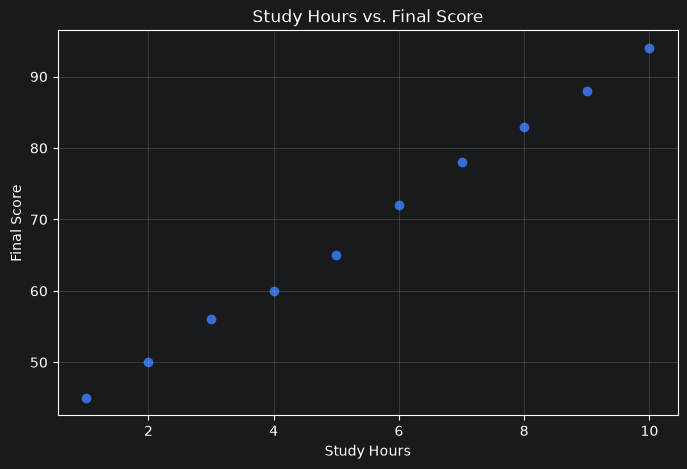

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df["study_hours"], df["final_score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs. Final Score")
plt.grid(alpha=0.3)
plt.show()

# Part 2 — Build Linear Regression From Scratch

In this section, you will translate the mathematical equations discussed in the lecture into Python code.

Each step provides:

- The mathematical equation you need.
- A short implementation hint.
- An incomplete code cell for you to finish.

You may use `NumPy`, `Pandas`, and `Matplotlib`, but you must **not** use `scikit-learn` in this section.

## Step 1 — Prepare the Feature and Target

Create:

- `x`: the input feature containing study hours.
- `y`: the target containing final scores.
- `m`: the number of training examples.

**Hint:** Convert the Pandas columns into NumPy arrays using `.to_numpy(dtype=float)`.

In [8]:
# TODO: Create x, y, and m.

x = df["study_hours"].to_numpy(dtype=float)
y = df["final_score"].to_numpy(dtype=float)
m = df.shape[0]

print("x:", x)
print("y:", y)
print("Number of examples:", m)

x: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
y: [45. 50. 56. 60. 65. 72. 78. 83. 88. 94.]
Number of examples: 10


## Step 2 — Initialize the Model Parameters

Start with:


$$
\theta_0 = 0
$$


$$
\theta_1 = 0
$$


Also choose:

- A learning rate $\alpha$
- A number of training iterations

**Hint:** You may start with `learning_rate = 0.01` and `iterations = 2000`.

In [12]:
# TODO: Initialize the parameters and training settings.

theta_0 = 0.0
theta_1 = 0.0
learning_rate = 0.01
iterations = 2000

print("Initial intercept:", theta_0)
print("Initial slope:", theta_1)

Initial intercept: 0.0
Initial slope: 0.0


## Step 3 — Implement the Hypothesis Function

The prediction equation is:


$$
\hat{y} = h_\theta(x) = \theta_0 + \theta_1x
$$


**Hint:** NumPy can apply this equation to the entire `x` array at once.  
Your function should return one prediction for every input value.

In [10]:
def predict(x_values, theta_0, theta_1):
    # Translate the hypothesis equation into Python.
    y_hat = theta_0 + theta_1 * x_values
    return y_hat

## Step 4 — Calculate the Prediction Error

For each example:


$$
error_i = \hat{y}_i - y_i
$$


**Hint:** First generate predictions using your `predict()` function, then subtract the actual target array.

In [11]:
# TODO: Generate the initial predictions and calculate the errors.

initial_predictions = predict(x, theta_0, theta_1)
initial_errors = initial_predictions - y

error_table = pd.DataFrame({
    "actual": y,
    "predicted": initial_predictions,
    "error": initial_errors
})

display(error_table)

,actual,predicted,error
0,45.0,0.0,-45.0
1,50.0,0.0,-50.0
2,56.0,0.0,-56.0
3,60.0,0.0,-60.0
4,65.0,0.0,-65.0
5,72.0,0.0,-72.0
6,78.0,0.0,-78.0
7,83.0,0.0,-83.0
8,88.0,0.0,-88.0
9,94.0,0.0,-94.0


## Step 5 — Implement the Cost Function

Use the squared-error cost:


$$
J(\theta_0,\theta_1)
=
\frac{1}{2m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)^2
$$


**Hint:**

1. Generate predictions.
2. Calculate `predictions - y_values`.
3. Square the errors using `** 2`.
4. Sum them using `np.sum()`.
5. Divide by `2 * number_of_examples`.

In [13]:
def compute_cost(x_values, y_values, theta_0, theta_1):
    # Implement the cost equation.
    predictions = predict(x_values, theta_0, theta_1)
    errors = predictions - y_values
    cost = np.sum(errors ** 2) / (2 * len(y_values))
    return cost

In [14]:
# Calculate and print the initial cost.

initial_cost = compute_cost(x, y, theta_0, theta_1)
print("Initial cost:", initial_cost)

Initial cost: 2511.15


## Step 6 — Implement the Gradients

Gradient for the intercept:


$$
\frac{\partial J}{\partial \theta_0}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)
$$


Gradient for the slope:


$$
\frac{\partial J}{\partial \theta_1}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_i-y_i\right)x_i
$$


**Hint:**

- Calculate the predictions and errors first.
- `np.mean(errors)` gives the intercept gradient.
- Think about what must be multiplied by the errors for the slope gradient.

In [18]:
def compute_gradients(x_values, y_values, theta_0, theta_1):
    # Generate predictions.
    predictions = predict(x_values, theta_0, theta_1)

    # Calculate errors.
    errors = predictions - y_values

    # Calculate both gradients.
    gradient_0 = np.mean(errors) # intercept gradient
    gradient_1 = np.mean(errors * x_values) # slope gradient

    return gradient_0, gradient_1

## Step 7 — Perform One Parameter Update

Update the intercept:


$$
\theta_0
:=
\theta_0
-
\alpha
\frac{\partial J}{\partial \theta_0}
$$


Update the slope:


$$
\theta_1
:=
\theta_1
-
\alpha
\frac{\partial J}{\partial \theta_1}
$$


**Hint:** Calculate both gradients before updating either parameter.

In [19]:
# Use separate demo variables so the main training values are not changed yet.
theta_0_demo = 0.0
theta_1_demo = 0.0

# Calculate the gradients.
gradient_0, gradient_1 = compute_gradients(x, y, theta_0_demo, theta_1_demo)

# Update theta_0_demo and theta_1_demo.
theta_0_demo = theta_0_demo - learning_rate * gradient_0
theta_1_demo = theta_1_demo - learning_rate * gradient_1

print("Updated intercept:", theta_0_demo)
print("Updated slope:", theta_1_demo)
print("Cost after one update:", compute_cost(x, y, theta_0_demo, theta_1_demo))

Updated intercept: 0.691
Updated slope: 4.252
Cost after one update: 1019.8804185000001


## Step 8 — Build the Gradient Descent Training Loop

Your function should repeat the following process:

1. Calculate the gradients.
2. Update `theta_0`.
3. Update `theta_1`.
4. Calculate the new cost.
5. Add the cost to `cost_history`.

Return:

- The final intercept.
- The final slope.
- The full cost history.

**Hint:** Use a `for` loop with `range(iterations)`.

In [22]:
def gradient_descent(
    x_values,
    y_values,
    theta_0=0.0,
    theta_1=0.0,
    learning_rate=0.01,
    iterations=2000
):
    cost_history = []

    for iteration in range(iterations):
        # Calculate gradients.
        gradient_0, gradient_1 = compute_gradients(x_values, y_values, theta_0, theta_1)

        # Update theta_0 and theta_1.
        theta_0 = theta_0 - learning_rate * gradient_0
        theta_1 = theta_1 - learning_rate * gradient_1

        # Calculate and store the cost.
        cost = compute_cost(x_values, y_values, theta_0, theta_1)
        cost_history.append(cost)

    return theta_0, theta_1, cost_history

## Step 9 — Train the Manual Model

Call your Gradient Descent function using the provided dataset.

**Hint:** Store the returned values in:

- `learned_theta_0`
- `learned_theta_1`
- `cost_history`

In [23]:
# Train the model.

learned_theta_0, learned_theta_1, cost_history = gradient_descent(x, y, theta_0, theta_1, learning_rate=0.01, iterations=2000)

print("Learned intercept:", learned_theta_0)
print("Learned slope:", learned_theta_1)
print("Final cost:", cost_history[-1])

Learned intercept: 38.44076085106003
Learned slope: 5.553056692137298
Final cost: 0.2316942729719665


## Step 10 — Generate Final Predictions

Use the learned equation:


$$
\hat{y}
=
\theta_0
+
\theta_1x
$$


**Hint:** Reuse your `predict()` function with the learned parameter values.

In [24]:
# Generate predictions using the learned model.

manual_predictions = predict(x, learned_theta_0, learned_theta_1)

print(
    f"Final equation: y_hat = "
    f"{learned_theta_0:.2f} + "
    f"{learned_theta_1:.2f}x"
)

Final equation: y_hat = 38.44 + 5.55x


## Step 11 — Visualize the Training Process

Create two plots:

1. Cost against iteration.
2. Actual data points and the final fitted line.

**Hint:** Use `plt.plot(cost_history)` for the first chart and combine `plt.scatter()` with `plt.plot()` for the second.

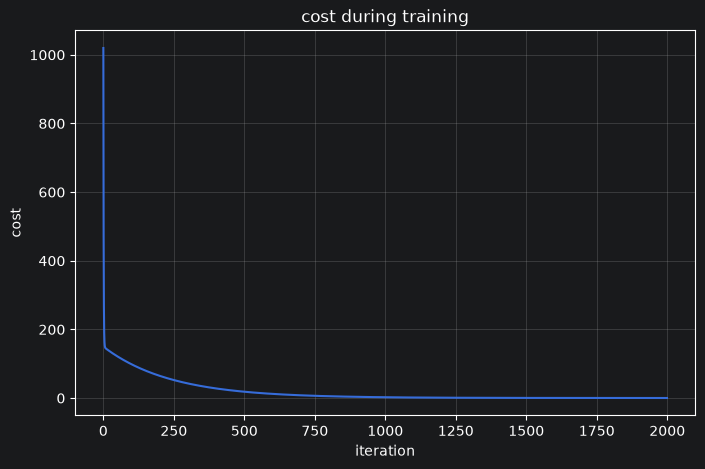

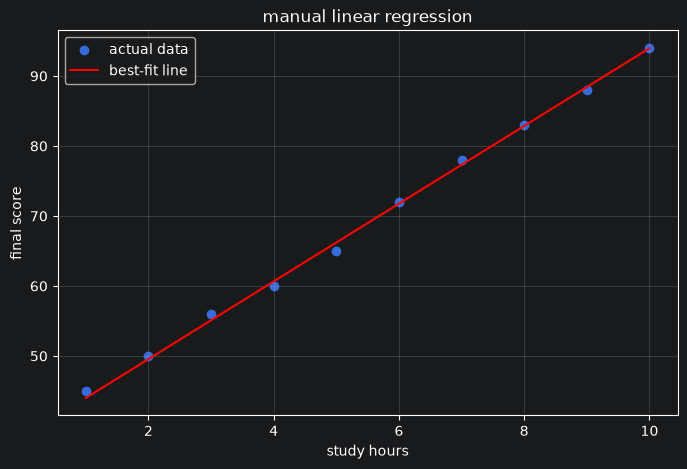

In [31]:
# Plot the cost history.
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("cost during training")
plt.grid(alpha=0.3)
plt.show()

# Plot the actual data and fitted line.
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="actual data")
plt.plot(x, manual_predictions, color="red", label="best-fit line")
plt.xlabel("study hours")
plt.ylabel("final score")
plt.title("manual linear regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 12 — Inspect Predictions and Residuals

Residual:


$$
residual_i = y_i - \hat{y}_i
$$


**Hint:** Build a DataFrame containing the input, actual target, prediction, and residual.

In [32]:
# Create and display the results table.

results = pd.DataFrame({
    "study_hours": x,
    "actual_score": y,
    "predicted_score": manual_predictions,
    "residual": y - manual_predictions
})

display(results.round(2))

,study_hours,actual_score,predicted_score,residual
0,1.0,45.0,43.99,1.01
1,2.0,50.0,49.55,0.45
2,3.0,56.0,55.10,0.90
3,4.0,60.0,60.65,-0.65
4,5.0,65.0,66.21,-1.21
5,6.0,72.0,71.76,0.24
6,7.0,78.0,77.31,0.69
7,8.0,83.0,82.87,0.13
8,9.0,88.0,88.42,-0.42
9,10.0,94.0,93.97,0.03


## Step 13 — Evaluate the Model Manually

Mean Absolute Error:


$$
MAE
=
\frac{1}{m}
\sum_{i=1}^{m}
|y_i-\hat{y}_i|
$$


Mean Squared Error:


$$
MSE
=
\frac{1}{m}
\sum_{i=1}^{m}
(y_i-\hat{y}_i)^2
$$


Root Mean Squared Error:


$$
RMSE = \sqrt{MSE}
$$


Coefficient of Determination:


$$
R^2
=
1
-
\frac{\sum(y_i-\hat{y}_i)^2}
{\sum(y_i-\bar{y})^2}
$$


**Hint:**

- Use `np.abs()` for MAE.
- Use `np.mean()` for averages.
- Use `np.sqrt()` for RMSE.
- The numerator of $R^2$ is the residual sum of squares.
- The denominator compares the actual values with their mean.

In [33]:
def regression_metrics(y_true, y_pred):
    # Calculate all four metrics.
    residuals = y_true - y_pred

    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals ** 2)
    rmse = np.sqrt(mse)

    sum_squared_residuals = np.sum(residuals ** 2)
    total_sum_of_squares = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - sum_squared_residuals / total_sum_of_squares

    return mae, mse, rmse, r2

In [34]:
# Evaluate the manual model.

manual_mae, manual_mse, manual_rmse, manual_r2 = regression_metrics(y, manual_predictions)

print("Manual MAE :", manual_mae)
print("Manual MSE :", manual_mse)
print("Manual RMSE:", manual_rmse)
print("Manual R²  :", manual_r2)

Manual MAE : 0.5728879445151229
Manual MSE : 0.463388545943933
Manual RMSE: 0.6807264839448609
Manual R²  : 0.998127647396081


## Step 14 — Predict a New Value

Predict the final score for a student who studies for **7.5 hours**.

**Hint:** Pass the new input and the learned parameters to your prediction function.

In [35]:
new_study_hours = 7.5

# Generate the new prediction.
predicted_score = predict(new_study_hours, learned_theta_0, learned_theta_1)

print(
    f"Predicted score for {new_study_hours} study hours: "
    f"{predicted_score:.2f}"
)

Predicted score for 7.5 study hours: 80.09


## Manual Implementation Checkpoint

Before moving to `scikit-learn`, verify that:

- The cost decreases during training.
- The final line follows the general trend of the data.
- The manual prediction function works for both arrays and single values.
- The evaluation metrics return numeric results.
- The learned intercept and slope are close to the later `scikit-learn` values.

In [36]:
# verifying that the cost decreases during training
print("first:", cost_history[0])
print("last:", cost_history[-1])
print("always decreasing:", np.all(np.diff(cost_history) < 0))

first: 1019.8804185000001
last: 0.2316942729719665
always decreasing: True


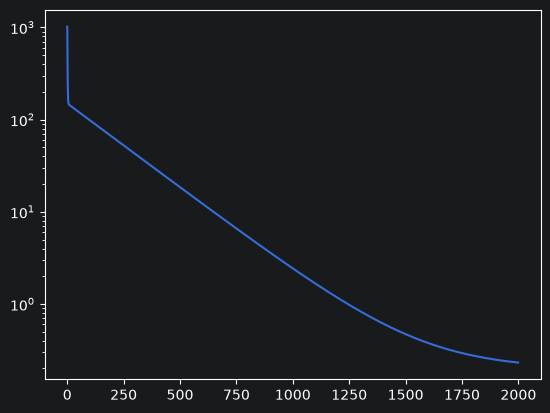

In [37]:
plt.plot(cost_history)
plt.yscale("log")

# Part 5 — Apply Linear Regression Using `scikit-learn`

Now we will implement the same model using `sklearn`.

> Important: `LinearRegression` hides the internal mathematical work.  
> It learns the ordinary least-squares solution using numerical linear algebra.  
> The manual implementation above was designed to make the learning process visible.

## 25. Import the Model and Metrics

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("scikit-learn imported successfully.")

scikit-learn imported successfully.


## 26. Prepare $X$ and $y$

`scikit-learn` expects `X` to be a two-dimensional table.

In [39]:
X_sklearn = df[["study_hours"]]
y_sklearn = df["final_score"]

print("X shape:", X_sklearn.shape)
print("y shape:", y_sklearn.shape)

X shape: (10, 1)
y shape: (10,)


## 27. Create and Train the Model

In [40]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_sklearn, y_sklearn)

print("Intercept:", sklearn_model.intercept_)
print("Coefficient:", sklearn_model.coef_[0])

Intercept: 38.99999999999999
Coefficient: 5.472727272727273


## 28. Make Predictions

In [41]:
sklearn_predictions = sklearn_model.predict(X_sklearn)

sklearn_results = df.copy()
sklearn_results["predicted_score"] = sklearn_predictions
sklearn_results["residual"] = (
    sklearn_results["final_score"]
    - sklearn_results["predicted_score"]
)

display(sklearn_results.round(2))

,study_hours,final_score,predicted_score,residual
0,1,45,44.47,0.53
1,2,50,49.95,0.05
2,3,56,55.42,0.58
3,4,60,60.89,-0.89
4,5,65,66.36,-1.36
5,6,72,71.84,0.16
6,7,78,77.31,0.69
7,8,83,82.78,0.22
8,9,88,88.25,-0.25
9,10,94,93.73,0.27


## 29. Evaluate the `sklearn` Model

In [42]:
sklearn_mae = mean_absolute_error(
    y_sklearn,
    sklearn_predictions
)

sklearn_mse = mean_squared_error(
    y_sklearn,
    sklearn_predictions
)

sklearn_rmse = np.sqrt(sklearn_mse)

sklearn_r2 = r2_score(
    y_sklearn,
    sklearn_predictions
)

print("MAE :", sklearn_mae)
print("MSE :", sklearn_mse)
print("RMSE:", sklearn_rmse)
print("R²  :", sklearn_r2)

MAE : 0.5018181818181837
MSE : 0.39636363636363575
RMSE: 0.629574170661119
R²  : 0.9983984660537248


## 30. Compare the Manual and `sklearn` Results

The values should be very close.

A small difference may remain because our Gradient Descent stopped after a fixed number of iterations.

In [43]:
comparison_table = pd.DataFrame({
    "Method": ["From Scratch", "scikit-learn"],
    "Intercept": [
        learned_theta_0,
        sklearn_model.intercept_
    ],
    "Slope": [
        learned_theta_1,
        sklearn_model.coef_[0]
    ],
    "MAE": [
        manual_mae,
        sklearn_mae
    ],
    "RMSE": [
        manual_rmse,
        sklearn_rmse
    ],
    "R2": [
        manual_r2,
        sklearn_r2
    ]
})

display(comparison_table.round(4))

,Method,Intercept,Slope,MAE,RMSE,R2
0,From Scratch,38.4408,5.5531,0.5729,0.6807,0.9981
1,scikit-learn,39.0000,5.4727,0.5018,0.6296,0.9984


## 31. Visualize the `sklearn` Model

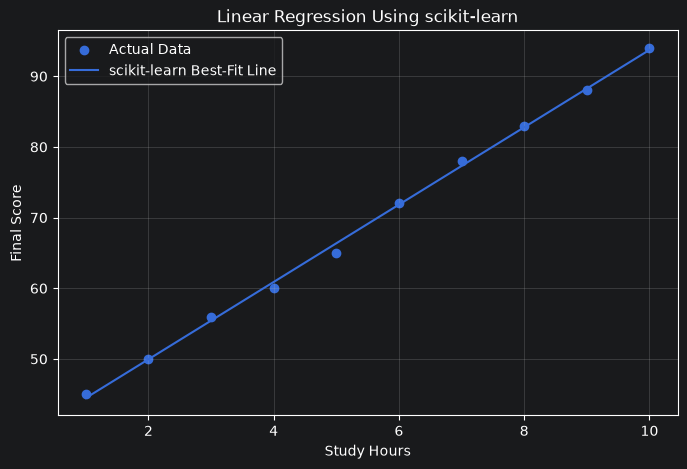

In [44]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_sklearn["study_hours"],
    y_sklearn,
    label="Actual Data"
)
plt.plot(
    X_sklearn["study_hours"],
    sklearn_predictions,
    label="scikit-learn Best-Fit Line"
)
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Linear Regression Using scikit-learn")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 6 — Practical Workflow with Train/Test Split

In real projects, we should not evaluate the final model only on the same data used for training.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sklearn,
    y_sklearn,
    test_size=0.2,
    random_state=42
)

print("Training examples:", len(X_train))
print("Testing examples :", len(X_test))

Training examples: 8
Testing examples : 2


In [46]:
test_model = LinearRegression()
test_model.fit(X_train, y_train)

test_predictions = test_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(
    mean_squared_error(y_test, test_predictions)
)
test_r2 = r2_score(y_test, test_predictions)

print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²  :", test_r2)

test_results = pd.DataFrame({
    "study_hours": X_test["study_hours"],
    "actual_score": y_test,
    "predicted_score": test_predictions
})

display(test_results.round(2))

Test MAE : 0.2198275862068968
Test RMSE: 0.2528817266184903
Test R²  : 0.9998228554912534


,study_hours,actual_score,predicted_score
8,9,88,88.34
1,2,50,49.91


> **Teaching Note:** This dataset is intentionally small.  
> With only two test examples, the test metrics can change considerably depending on the split.  
> Real projects require more observations and more reliable validation.

# Part 7 — Final Student Task

## Scenario

A training center wants to estimate a student's assessment score based on the number of completed practice sessions.

Each row represents one student.

### Required Work

Complete the task **from the beginning**:

1. Create and inspect the dataset.
2. Define the feature and target.
3. Visualize the relationship.
4. Build Simple Linear Regression manually.
5. Implement the cost function.
6. Implement Gradient Descent.
7. Plot the cost history.
8. Plot the best-fit line.
9. Calculate MAE, MSE, RMSE, and $R^2$ manually.
10. Predict the score for a student who completes 11 sessions.
11. Repeat the model using `scikit-learn`.
12. Compare both implementations.
13. Interpret the intercept, slope, and model performance.

In [47]:
task_data = {
    "practice_sessions": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14],
    "assessment_score": [42, 47, 51, 55, 61, 66, 70, 74, 80, 84, 91, 97]
}

task_df = pd.DataFrame(task_data)
display(task_df)

,practice_sessions,assessment_score
0,1,42
1,2,47
2,3,51
3,4,55
4,5,61
5,6,66
6,7,70
7,8,74
8,9,80
9,10,84


## Task 1 — Understand the Data

Answer:

- What does each row represent?
- How many rows and columns are there?
- Which column is the feature?
- Which column is the target?
- Why is this a regression problem?

In [ ]:
# YOUR CODE HERE
# Display shape, data types, missing values, and descriptive statistics.

pass

## Task 2 — Visualize the Relationship

In [ ]:
# YOUR CODE HERE
# Create a scatter plot.

pass

## Task 3 — Prepare $x$ and $y$

In [ ]:
# YOUR CODE HERE

pass

## Task 4 — Implement the Hypothesis Function

In [ ]:
# YOUR CODE HERE
# def task_predict(...):

pass

## Task 5 — Implement the Cost Function

In [ ]:
# YOUR CODE HERE
# def task_compute_cost(...):

pass

## Task 6 — Implement the Gradients

In [ ]:
# YOUR CODE HERE
# def task_compute_gradients(...):

pass

## Task 7 — Implement Gradient Descent

In [ ]:
# YOUR CODE HERE
# def task_gradient_descent(...):

pass

## Task 8 — Train the Manual Model

In [ ]:
# Suggested starting values:
# theta_0 = 0.0
# theta_1 = 0.0
# learning_rate = 0.005
# iterations = 3000

# YOUR CODE HERE

pass

## Task 9 — Plot the Cost and Best-Fit Line

In [ ]:
# YOUR CODE HERE

pass

## Task 10 — Evaluate the Manual Model

In [ ]:
# YOUR CODE HERE
# Calculate MAE, MSE, RMSE, and R² without sklearn.

pass

## Task 11 — Make a New Prediction

Predict the assessment score for **11 practice sessions**.

In [ ]:
# YOUR CODE HERE

pass

## Task 12 — Repeat Using `scikit-learn`

In [51]:
# YOUR CODE HERE
# Create X and y
X_task = task_df[["practice_sessions"]]
y_task = task_df["assessment_score"]

print("X shape:", X_task.shape)
print("y shape:", y_task.shape)

X shape: (12, 1)
y shape: (12,)


In [53]:
# fit LinearRegression
task_model = LinearRegression()
task_model.fit(X_task, y_task)

print("Intercept:", task_model.intercept_)
print("Coefficient:", task_model.coef_[0])

Intercept: 38.610565684899484
Coefficient: 4.378681626928472


In [57]:
# predict
task_predictions = task_model.predict(X_task)

In [58]:
# evaluate
task_mae = mean_absolute_error(y_task, task_predictions)
task_mse = mean_squared_error(y_task, task_predictions)
task_rmse = np.sqrt(task_mse)
task_r2 = r2_score(y_task, task_predictions)

print("MAE :", task_mae)
print("MSE :", task_mse)
print("RMSE:", task_rmse)
print("R²  :", task_r2)

MAE : 1.04932211313698
MSE : 1.67547140408291
RMSE: 1.294400017028318
R²  : 0.9941513652141002


## Task 13 — Interpretation Questions

Write your answers:

1. What does the slope mean in this dataset?
* slope = 4.38. each extra practice session adds about 4.4 points to the predicted score.

2. Is the intercept practically meaningful? Explain.
* intercept = 38.61. score with zero sessions. not useful. no one in our data did zero.

3. Did the cost decrease during training?
* yes. cost dropped every iteration and flattened out.

4. Were the manual and `sklearn` results close?
* yes, very close.

5. What does the RMSE tell us?
* RMSE = 1.29. the model is typically off by about 1.3 points.

6. What does the $R^2$ score tell us?
* $R^2$ = 0.994. the line explains 99.4% of the variation in scores.

7. Can this analysis prove that practice sessions cause higher scores?
*

8. What other features could improve the model?
* study hours, attendance, sleep, prior grades.

In [ ]:
# 1.

# 2.

# 3.

# 4.

# 5.

# 6.

# 7.

# 8.

# Submission Checklist

- [ ] I identified the feature and target correctly.
- [ ] I visualized the relationship before modeling.
- [ ] I implemented prediction, cost, gradients, and Gradient Descent.
- [ ] I plotted the cost history.
- [ ] I plotted the best-fit line.
- [ ] I calculated regression metrics manually.
- [ ] I implemented the model using `scikit-learn`.
- [ ] I compared and interpreted both implementations.
- [ ] I answered the interpretation questions in my own words.